In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [31]:
def simple_flat(data, value):
    return value + 0*data

In [32]:

omittedplots_numbers = [
    1,
    5,
    6,
    8,
    10,
    11,
    13,
    14,
    15,
    21,
    23,
    25,
    27,
    28,
    29,
    30,
    32,
    33,
    35,
    36,
    38,
    ]
omitted_indices = np.array(omittedplots_numbers) - 1


LINUX_DIRECTORY = "/home/u20482jg/MPHYS_Project_Local"

data_path = f"{LINUX_DIRECTORY}/results_files/2D_MCMC_to_gaussian_results.csv"

ps_fitdata = np.genfromtxt(data_path, delimiter=",", dtype=str, skip_header=1)

reg_names = ps_fitdata[:,0]
# l_terrors = np.array(ps_fitdata[:,1], dtype=float)
# lterror_uncs = np.array(ps_fitdata[:,2], dtype=float)
# b_terrors = np.array(ps_fitdata[:,3], dtype=float)
# bterror_uncs = np.array(ps_fitdata[:,4], dtype=float)
# l_sigmas = np.array(ps_fitdata[:,5], dtype=float)
# lsigma_uncs = np.array(ps_fitdata[:,6], dtype=float)
# b_sigmas = np.array(ps_fitdata[:,7], dtype=float)
# bsigma_uncs = np.array(ps_fitdata[:,8], dtype=float)

reg_truels = []
l_terrors = []
lterror_uncs = []
b_terrors = []
bterror_uncs = []
l_sigmas = []
lsigma_uncs = []
b_sigmas = []
bsigma_uncs = []
for i, reg in enumerate(reg_names):
    if i not in omitted_indices:
        reg_truels.append(float(reg[1:8]))
        l_terrors.append(float(ps_fitdata[i,1]))
        lterror_uncs.append(float(ps_fitdata[i,2]))
        b_terrors.append(float(ps_fitdata[i,3]))
        bterror_uncs.append(float(ps_fitdata[i,4]))
        l_sigmas.append(float(ps_fitdata[i,5]))
        lsigma_uncs.append(float(ps_fitdata[i,6]))
        b_sigmas.append(float(ps_fitdata[i,7]))
        bsigma_uncs.append(float(ps_fitdata[i,8]))

lterrors_fit = curve_fit(simple_flat, reg_truels, l_terrors,
                         p0 = np.mean(l_terrors),
                         sigma=lterror_uncs,
                         method='lm'
                         )
lterrors_numres = lterrors_fit[0]
lterrors_numuncs = [
    lterrors_fit[0][0]
    ]

bterrors_fit = curve_fit(simple_flat, reg_truels, b_terrors,
                         p0 = np.mean(b_terrors),
                         sigma=bterror_uncs,
                         method='lm'
                         )
bterrors_numres = bterrors_fit[0]
bterrors_numuncs = [
    bterrors_fit[0][0]
    ]

lsigmas_fit = curve_fit(simple_flat, reg_truels, l_sigmas,
                         p0 = np.mean(l_sigmas),
                         sigma=lsigma_uncs,
                         method='lm'
                         )
lsigmas_numres = lsigmas_fit[0]
lsigmas_numuncs = [
    lsigmas_fit[0][0]
    ]

bsigmas_fit = curve_fit(simple_flat, reg_truels, b_sigmas,
                         p0 = np.mean(b_sigmas),
                         sigma=bsigma_uncs,
                         method='lm'
                         )
bsigmas_numres = bsigmas_fit[0]
bsigmas_numuncs = [
    bsigmas_fit[0][0]
    ]

print(f"""
δl = {lterrors_numres[0]: .4f} +/- {lterrors_numuncs[0]: .4f} arcmin
δb = {bterrors_numres[0]: .4f} +/- {bterrors_numuncs[0]: .4f} arcmin
σ_l = {lsigmas_numres[0]: .4f} +/- {lsigmas_numuncs[0]: .4f} arcmin
σ_b = {bsigmas_numres[0]: .4f} +/- {bsigmas_numuncs[0]: .4f} arcmin
""")


δl = -0.0196 +/- -0.0196 arcmin
δb =  0.9240 +/-  0.9240 arcmin
σ_l =  2.2805 +/-  2.2805 arcmin
σ_b =  2.3266 +/-  2.3266 arcmin



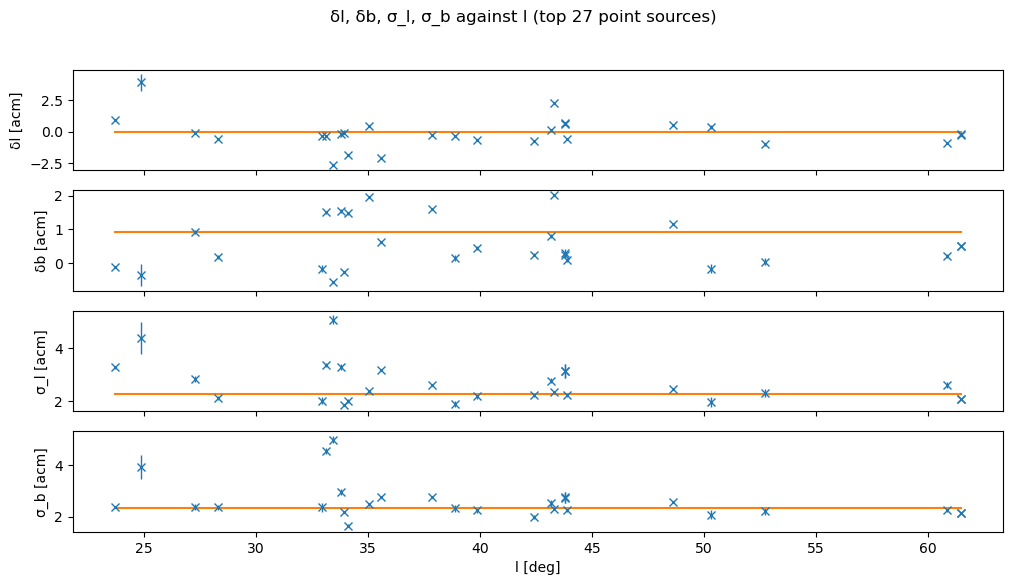

In [33]:
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(12,6), sharex= True)
if len(omitted_indices) == 0:
    figtitle = "δl, δb, σ_l, σ_b against l (all point sources)"
    savefig_path = f"{LINUX_DIRECTORY}/figures/tracking_errors_and_sigmas_against_l.png"
else:
    figtitle = f"δl, δb, σ_l, σ_b against l (top {len(reg_names) - len(omitted_indices)} point sources)"
    savefig_path = f"{LINUX_DIRECTORY}/figures/tracking_errors_and_sigmas_against_l_cut.png"

line_x = np.linspace(np.min(reg_truels), np.max(reg_truels), 1000)

lt_ax = axs[0]
lt_ax.errorbar(reg_truels, l_terrors, lterror_uncs,
               marker = 'x',
               linewidth = 0,
               elinewidth = 1)
lt_ax.plot(
    line_x,
    simple_flat(line_x, lterrors_numres[0])
           )
# lt_ax.set_xlabel("l [deg]")
lt_ax.set_ylabel("δl [acm]")

bt_ax = axs[1]
bt_ax.errorbar(reg_truels, b_terrors, bterror_uncs,
               marker = 'x',
               linewidth = 0,
               elinewidth = 1)
bt_ax.plot(
    line_x,
    simple_flat(line_x, bterrors_numres[0])
           )
# bt_ax.set_xlabel("l [deg]")
bt_ax.set_ylabel("δb [acm]")

ls_ax = axs[2]
ls_ax.errorbar(reg_truels, l_sigmas, lsigma_uncs,
               marker = 'x',
               linewidth = 0,
               elinewidth = 1)
ls_ax.plot(
    line_x,
    simple_flat(line_x, lsigmas_numres[0])
           )
ls_ax.set_ylabel("σ_l [acm]")

bs_ax = axs[3]
bs_ax.errorbar(reg_truels, b_sigmas, bsigma_uncs,
               marker = 'x',
               linewidth = 0,
               elinewidth = 1)
bs_ax.plot(
    line_x,
    simple_flat(line_x, bsigmas_numres[0])
           )
bs_ax.set_xlabel("l [deg]")
bs_ax.set_ylabel("σ_b [acm]")

fig.suptitle(figtitle)

plt.savefig(savefig_path, dpi=300)
plt.show()